<a href="https://colab.research.google.com/github/Prajwal-Luitel/Twitter-Sentiment-Analysis/blob/main/Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install kagglehub[pandas-datasets]

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "twitter_training.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "jp797498e/twitter-entity-sentiment-analysis",
  file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
First 5 records:    2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     


In [4]:
df.columns=['id','information','label','tweet']
df.head()

,id,information,label,tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


# EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           74681 non-null  int64 
 1   information  74681 non-null  object
 2   label        74681 non-null  object
 3   tweet        73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [153]:
df.dropna(inplace=True)

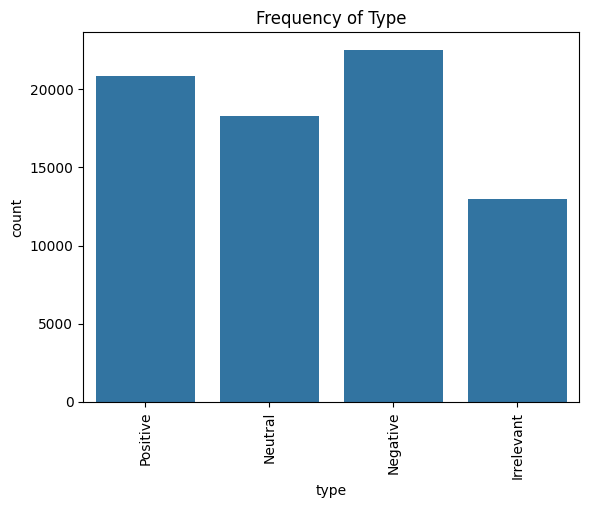

In [ ]:
sns.countplot(data=df, x="tweet")
plt.xticks(rotation=90)
plt.title("Frequency of Type")
plt.show()


In [6]:
plot=df.groupby(by=["information","label"]).count().reset_index()
plot.head()

,information,label,id,tweet
0,Amazon,Irrelevant,192,186
1,Amazon,Negative,576,575
2,Amazon,Neutral,1236,1207
3,Amazon,Positive,312,308
4,ApexLegends,Irrelevant,192,192


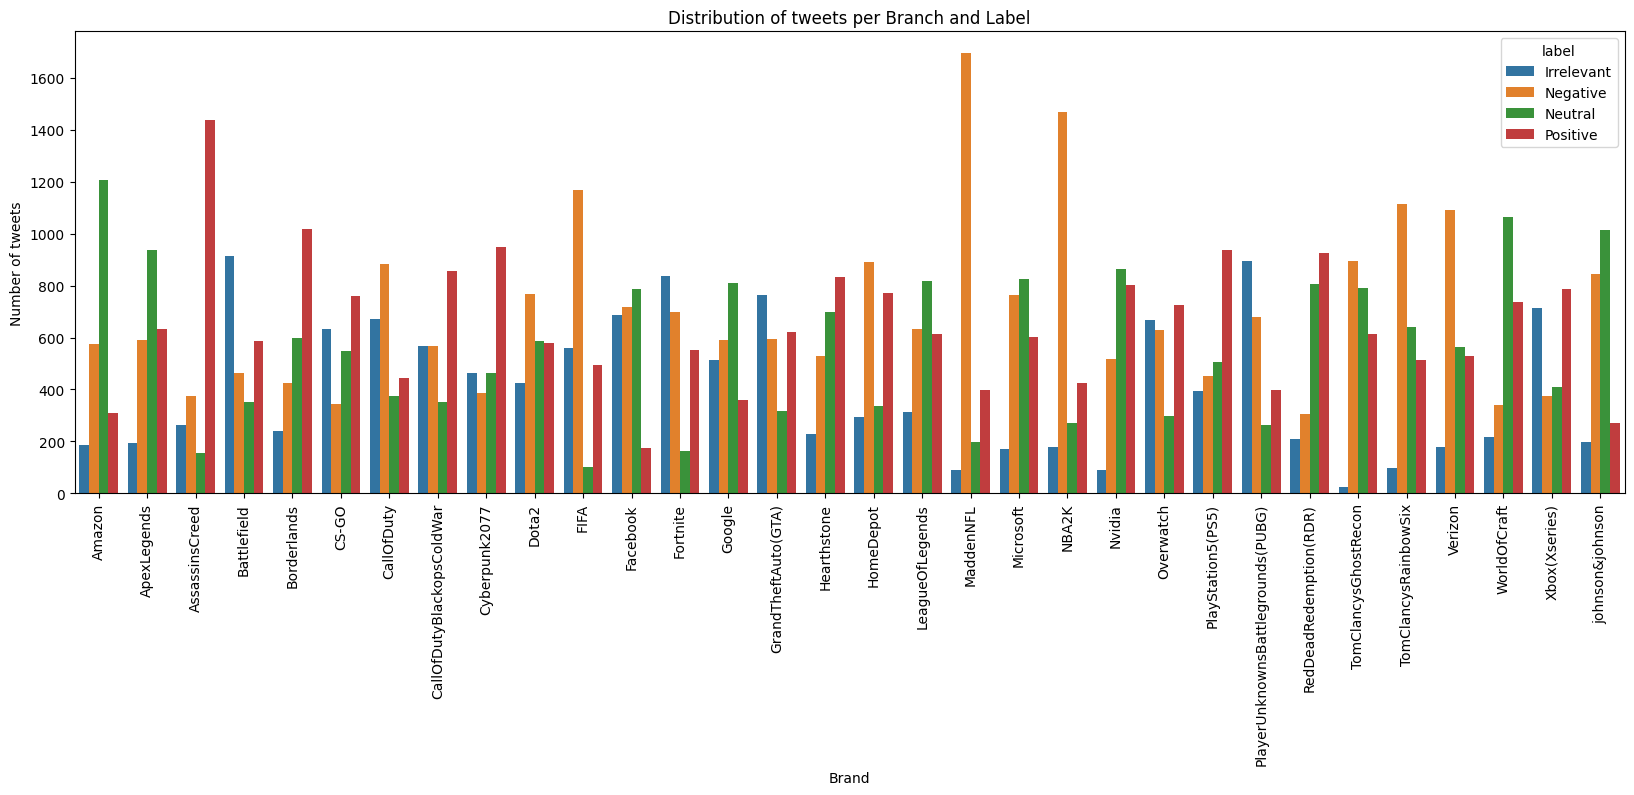

In [ ]:
#Figure of comparison per label
plt.figure(figsize=(20,6))
sns.barplot(data=plot,x="information",y="id",hue="label")
plt.xticks(rotation=90)
plt.xlabel("Brand")
plt.ylabel("Number of tweets")
plt.title("Distribution of tweets per Branch and Label");

# Word Clouds

In [41]:
tweet = df["tweet"]
all_text = tweet.str.cat(sep=" ").lower()

tweet = df[df["label"]=="Positive"]["tweet"]
positive_text = tweet.str.cat(sep=" ").lower()

tweet = df[df["label"]=="Negative"]["tweet"]
negative_text = tweet.str.cat(sep=" ").lower()


In [39]:
from wordcloud import WordCloud #Word visualization

In [38]:
def generate_word_cloud(text,title="Tweets"):
  #Creation of wordcloud
  wordcloud = WordCloud(
    width=1500,
    height=1000,
    max_words=150,
    random_state=42,
    collocations=False,
    background_color="white"
  ).generate(text)

  #Figure properties
  plt.figure(figsize=(14,8))
  plt.imshow(wordcloud, interpolation="bilinear")
  plt.axis("off")
  plt.title(f"Word Cloud For: {title}", fontsize=40)
  plt.show()




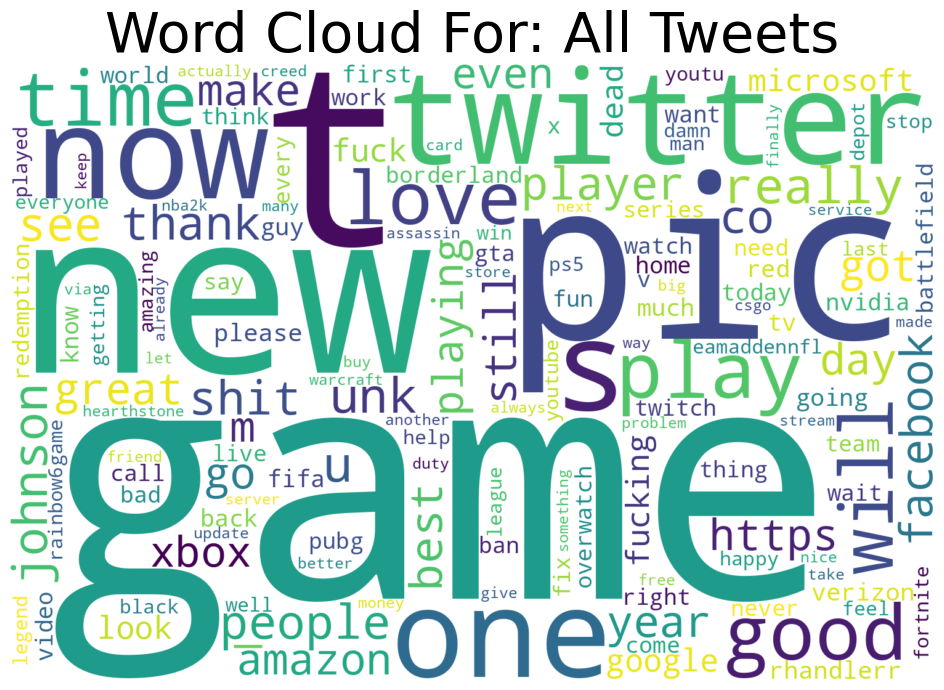

In [43]:
generate_word_cloud(all_text,"All Tweets")

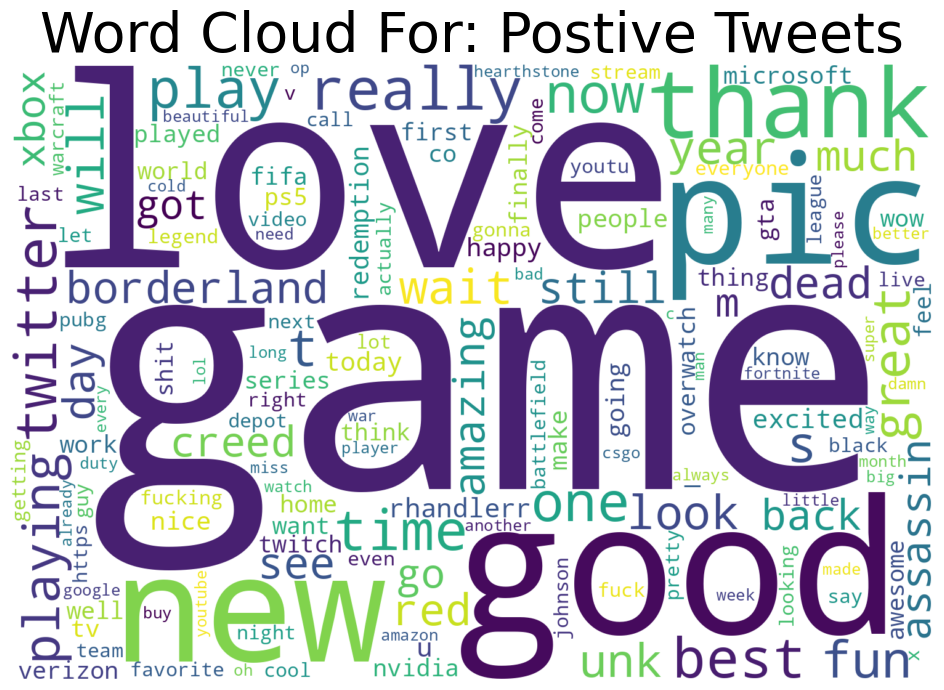

In [44]:
generate_word_cloud(positive_text,"Postive Tweets")

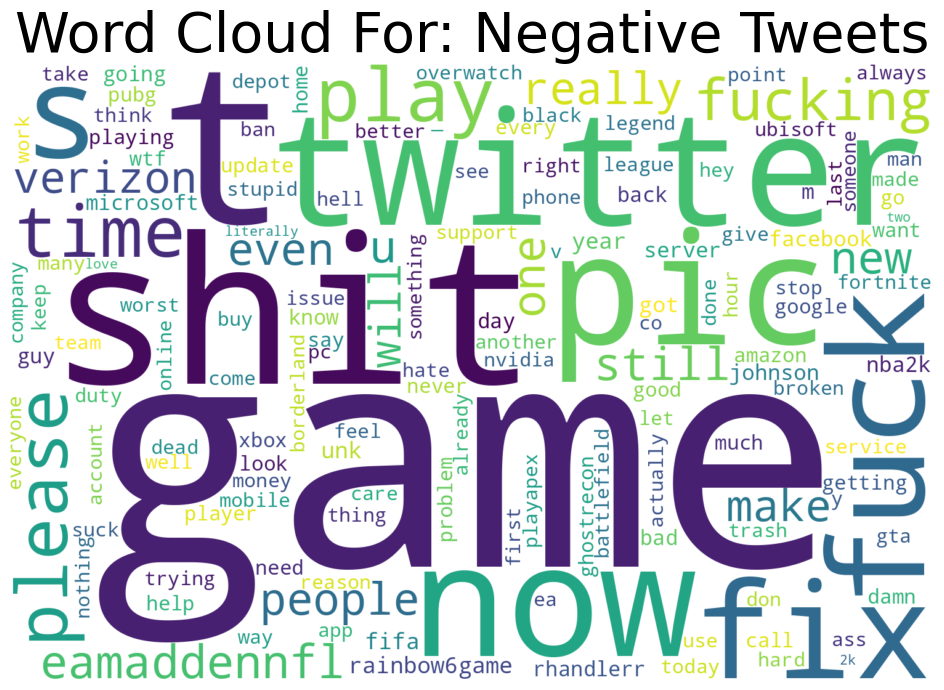

In [45]:
generate_word_cloud(negative_text,"Negative Tweets")

# Text Preprocessing

In [144]:
import nltk
import string

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize the lemmatizer
wnl = WordNetLemmatizer()

def preprocessing(raw_text):
  stop_words = set(stopwords.words("english"))

  raw_text = str(raw_text)
  # Use word_tokenize for better tokenization before lemmatization
  words = word_tokenize(raw_text.lower())

  filtered_words = [word for word in words if word not in stop_words and word not in string.punctuation]
  lemmas = [wnl.lemmatize(word,pos="v") for word in filtered_words]
  return " ".join(lemmas)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [145]:
df['Preprocessed_Text'] = df['tweet'].apply(preprocessing)

In [148]:
df.sample(7)

,id,information,label,tweet,Preprocessed_Text
40495,1350,Battlefield,Neutral,I won 2 achievements in Battlefield V for 31 T...,2 achievements battlefield v 31 truefield pts ...
3641,1830,CallOfDutyBlackopsColdWar,Negative,it's trash.,'s trash
50608,6287,FIFA,Negative,Yall again why nobody wanted FIFA 2017 Austral...,yall nobody want fifa 2017 australia ’ shit fu...
8377,9437,Overwatch,Negative,"Oh hell, we're going again.",oh hell 're go
31946,7483,LeagueOfLegends,Neutral,Avril Lavigne and league of legends I’m really...,avril lavigne league legends ’ really bad dawg
72253,11179,TomClancysGhostRecon,Neutral,Me too haha!,haha
29756,717,ApexLegends,Neutral,For a while now I have been working on wall ju...,work wall jump train finally begin pay financi...


## Label Encoding

In [149]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [150]:
df

,id,information,label,tweet,Preprocessed_Text
0,2401,Borderlands,3,I am coming to the borders and I will kill you...,come border kill
1,2401,Borderlands,3,im getting on borderlands and i will kill you ...,im get borderlands kill
2,2401,Borderlands,3,im coming on borderlands and i will murder you...,im come borderlands murder
3,2401,Borderlands,3,im getting on borderlands 2 and i will murder ...,im get borderlands 2 murder
4,2401,Borderlands,3,im getting into borderlands and i can murder y...,im get borderlands murder
...,...,...,...,...,...
74676,9200,Nvidia,3,Just realized that the Windows partition of my...,realize windows partition mac like 6 years beh...
74677,9200,Nvidia,3,Just realized that my Mac window partition is ...,realize mac window partition 6 years behind nv...
74678,9200,Nvidia,3,Just realized the windows partition of my Mac ...,realize windows partition mac 6 years behind n...
74679,9200,Nvidia,3,Just realized between the windows partition of...,realize windows partition mac like 6 years beh...


# Train Test Split

In [154]:
from sklearn.model_selection import train_test_split
X = df['Preprocessed_Text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [155]:
X_train.shape,X_test.shape

((59196,), (14799,))

# Training Model

In [157]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

## Random Forest

In [158]:
random_forest = Pipeline([
    ('vectorizer_tri_grams', TfidfVectorizer()),
    ('naive_bayes', (RandomForestClassifier(random_state=42)))
])

In [159]:
random_forest.fit(X_train, y_train)

Pipeline(steps=[('vectorizer_tri_grams', TfidfVectorizer()),
                ('naive_bayes', RandomForestClassifier(random_state=42))])

In [160]:
print(classification_report(y_test, random_forest.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.87      0.92      2624
           1       0.93      0.93      0.93      4463
           2       0.95      0.90      0.92      3589
           3       0.87      0.95      0.91      4123

    accuracy                           0.92     14799
   macro avg       0.93      0.92      0.92     14799
weighted avg       0.92      0.92      0.92     14799



#Model Evalutation

In [171]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Confusion Matrix
def display_confusion_matrix(y_true, y_pred, title=None):
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title(f"Confusion Matrix for {title}")
  plt.show()



In [177]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def display_ROC(y_true, y_pred,classes_, title=None):
  y_test_bin = label_binarize(y_test, classes=classes_)

  # Predict probabilities for all classes
  y_prob = random_forest.predict_proba(X_test)

  plt.figure(figsize=(8, 6))

  for i, class_label in enumerate(classes_):
      fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
      roc_auc = auc(fpr, tpr)
      plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc:.2f})")

  plt.plot([0, 1], [0, 1], linestyle='--')
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title(f"Multi-Class ROC Curve for {title}")
  plt.legend()
  plt.show()


In [174]:
from sklearn.metrics import classification_report
def display_classification_report(y_true, y_pred):
  print(classification_report(y_true, y_pred))

In [169]:
y_pred = random_forest.predict(X_test)

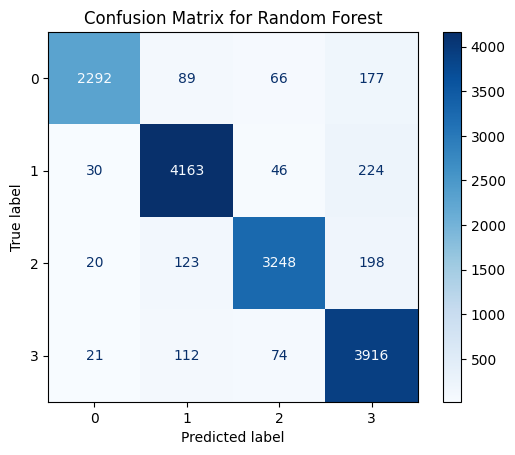

In [175]:
display_confusion_matrix(y_test, y_pred, title="Random Forest")

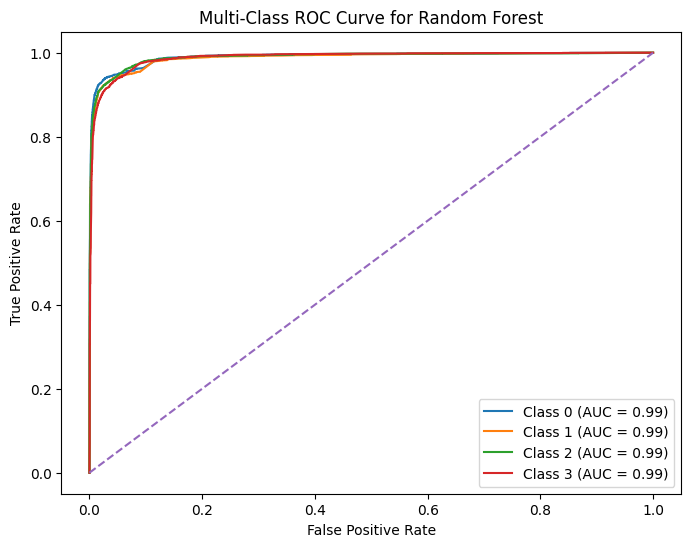

In [178]:
display_ROC(y_test, y_pred, random_forest.classes_, title="Random Forest")

In [180]:
classification_report = display_classification_report(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.97      0.87      0.92      2624
           1       0.93      0.93      0.93      4463
           2       0.95      0.90      0.92      3589
           3       0.87      0.95      0.91      4123

    accuracy                           0.92     14799
   macro avg       0.93      0.92      0.92     14799
weighted avg       0.92      0.92      0.92     14799

